In [1]:
import polars as pl
import os 
import requests
import matplotlib.pyplot as plt
from datetime import datetime, timezone
import numpy as np

QUESTDB_ENDPOINT = "https://timeseriesdbfrancesco.dev.rd.areasciencepark.it"
def get_table_data(filename, query: str) -> pl.DataFrame:
    filename = str(filename)
    if os.path.exists(filename):
        return pl.read_ipc(filename)
    response = requests.get(f"{QUESTDB_ENDPOINT}/exec", params={"query": query},
                            verify=False, timeout=60)
    response.raise_for_status()
    payload = response.json()
    df = pl.DataFrame(payload["dataset"], schema=[c["name"] for c in payload["columns"]],
                      orient="row")
    if "timestamp" in df.columns:
        df = df.with_columns(
            pl.col("timestamp").str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%S%.fZ", strict=False))
    #df.write_ipc(filename)
    return df

In [ ]:
LCST_STATS_PATH = lambda model_name, gen_toks : f"./logs/stats_{model_name}_t{gen_toks}__stats_history.csv"

GEN_TOKENS = [
    250,
    500,
    1000,
    1500,
    3000,
    5000,
    8000
]
GEN_TOKENS = [str(n) for n in GEN_TOKENS]

MODELS = [
    "Qwen3.8",
    "Qwen3.6"
]

RESULTS = {}
for m in MODELS: 
    RESULTS[m] = {}
    for toks in GEN_TOKENS:
        RESULTS[m][toks] = {}

LCST = {}
# Read stats history for all models
for m in MODELS:
    LCST[m] = {}
    for toks in GEN_TOKENS:
        LCST[m][toks] = pl.read_csv(LCST_STATS_PATH(model_name=m, gen_toks=toks))

for m in MODELS:
    for toks in GEN_TOKENS:
        LCST[m][toks] = LCST[m][toks].with_columns(
            pl.from_epoch(pl.col("Timestamp"), time_unit="s").alias("Datetime")
        )


In [3]:
obsBegin = min( LCST[m][toks]["Timestamp"].min() for m in MODELS for toks in GEN_TOKENS )
obsEnd = max( LCST[m][toks]["Timestamp"].min() for m in MODELS for toks in GEN_TOKENS )

def ts_to_questdb_dt_format(ts):
    ts = str(ts).replace(" ", "T") + "Z"
    return ts
    

#"ipmi_power" : f"""
#SELECT timestamp, psu_id, value, unit
#FROM ipmi_power
#WHERE unit='W' AND '{ts_to_questdb_dt_format(obsBegin)}' < timestamp AND timestamp < '{ts_to_questdb_dt_format(obsEnd)}' AND psu_id=0
#""",
QUERIES = {
"nvidia_smi" : f"""
    SELECT timestamp, index, power_draw, utilization_memory, temperature_gpu, utilization_gpu
    FROM nvidia_smi
    WHERE '{ts_to_questdb_dt_format(obsBegin)}' < timestamp AND timestamp < '{ts_to_questdb_dt_format(obsEnd)}'
    """
}

In [4]:
DB = {}
for q in QUERIES: 
    DB[q] = get_table_data("",q)
    DB[q] = DB[q].rename({"timestamp": "Datetime"})
    DB[q] = DB[q].with_columns(
    (pl.col("Datetime").dt.timestamp("us") // 1e6).alias("Timestamp")
)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/urllib3/connectionpool.py:1129: InsecureRequestWarning: Unverified HTTPS request is being made to host 'timeseriesdbfrancesco.dev.rd.areasciencepark.it'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


# Identifiyng the GPU used by each benchmark

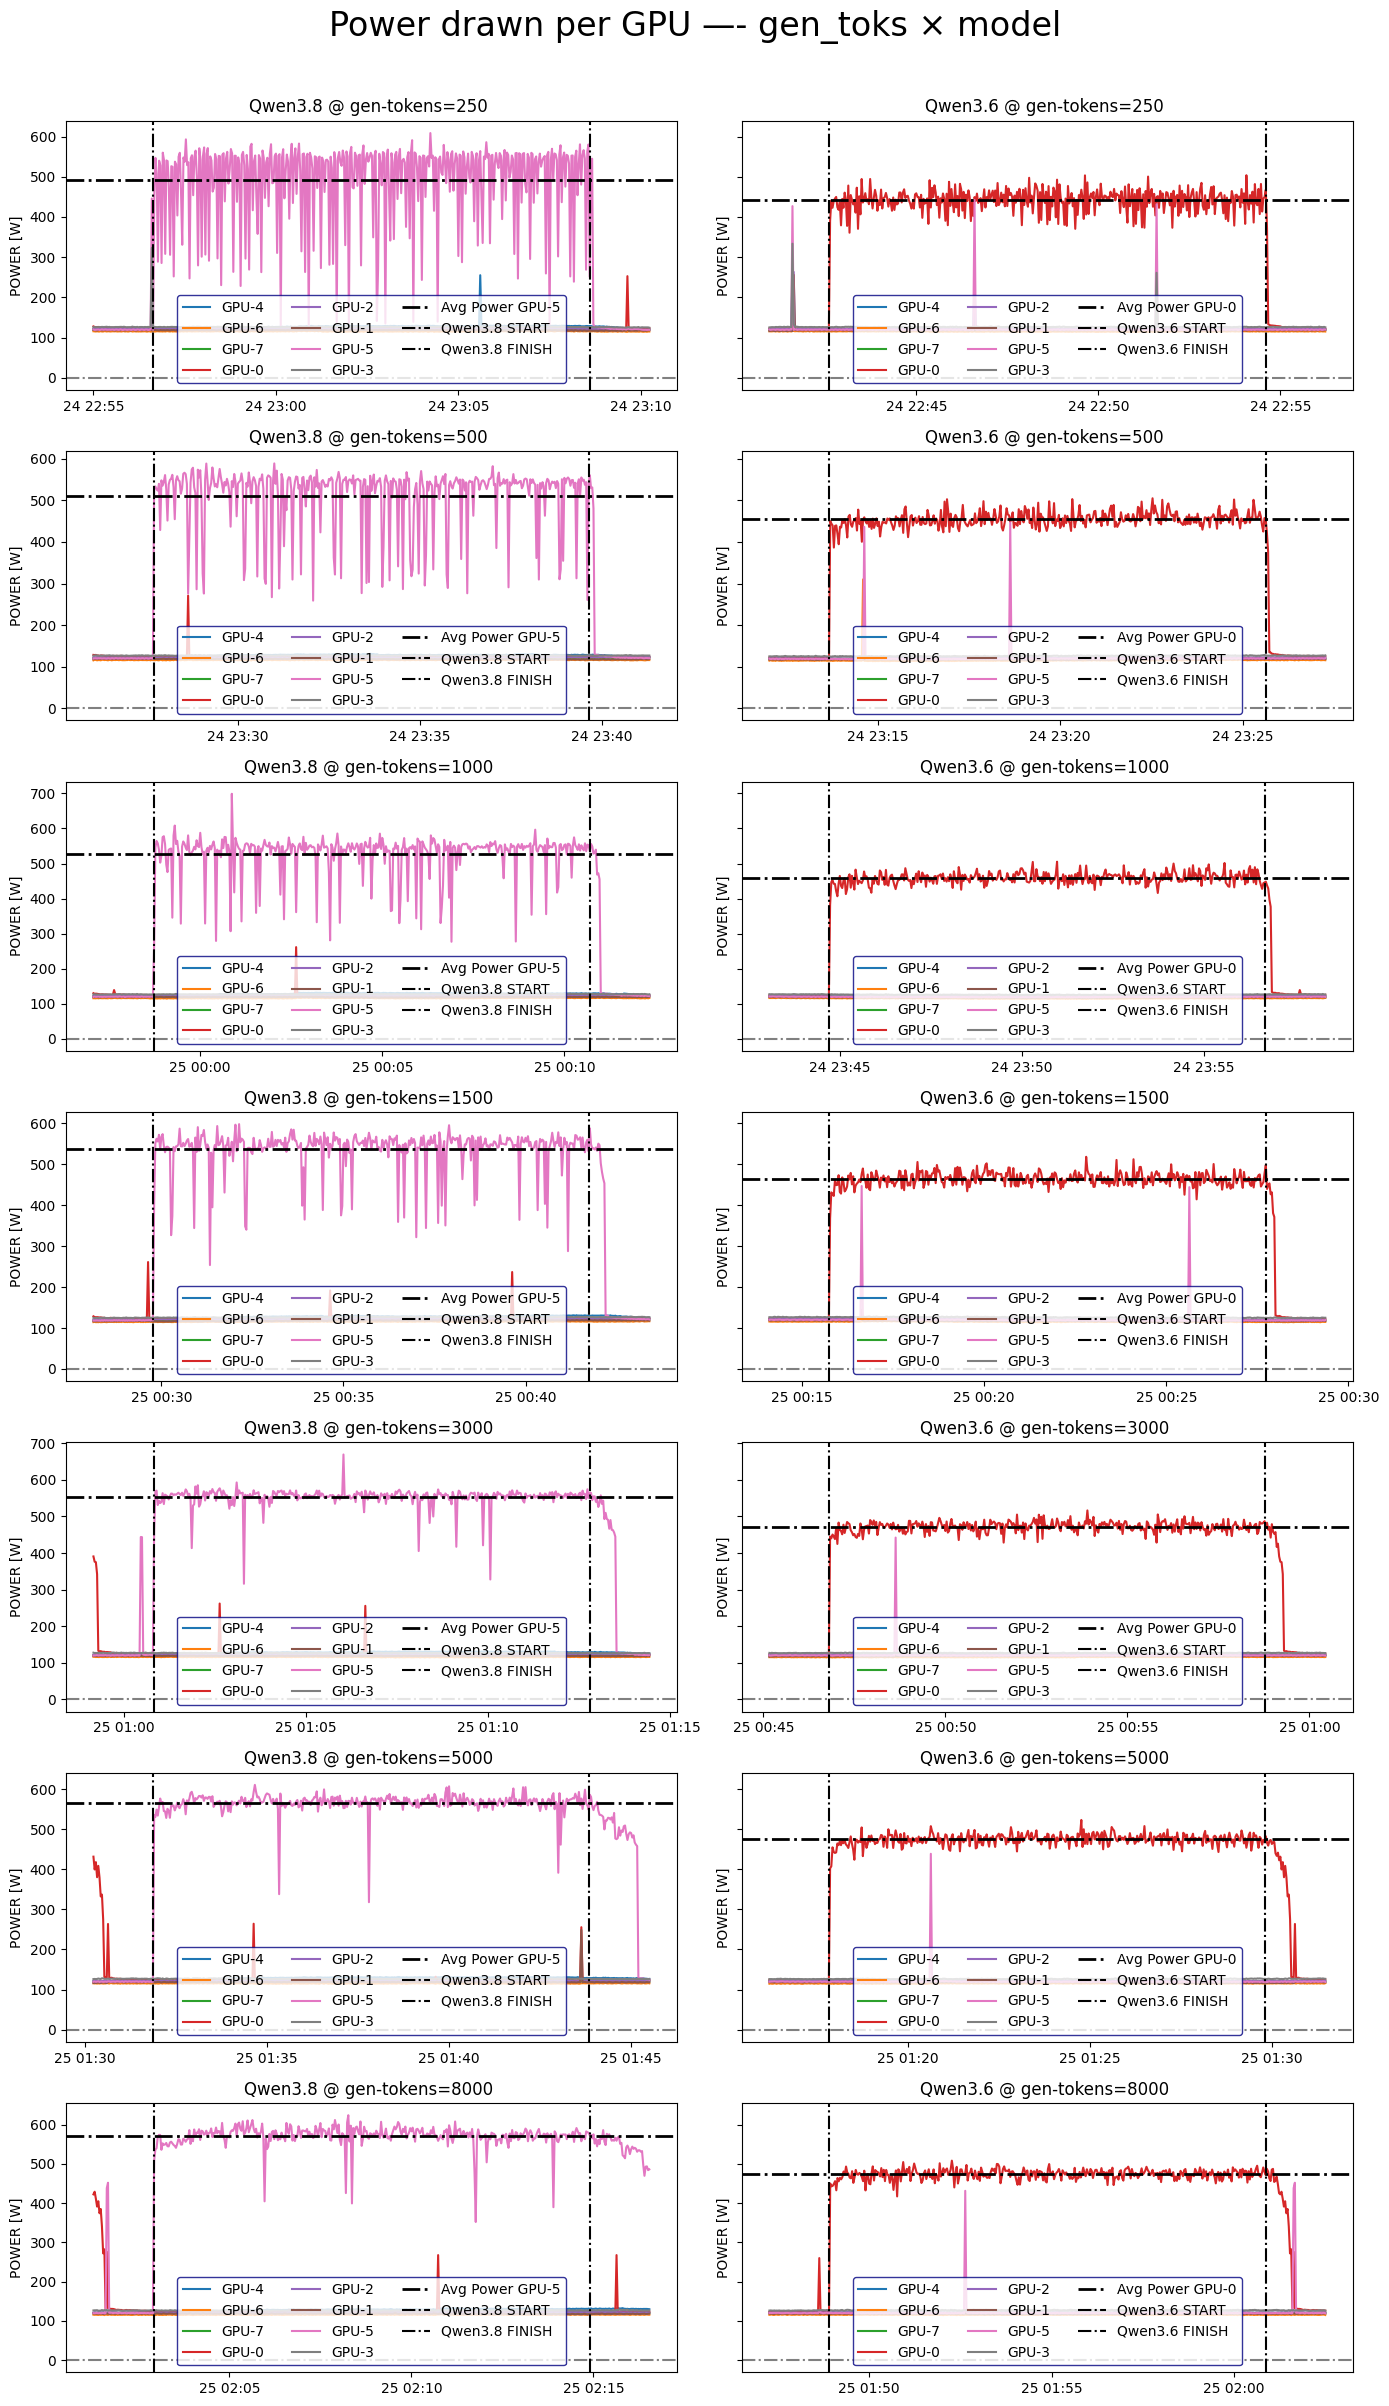

In [5]:
# GPU's are indexed by 'index'
df = DB["nvidia_smi"]

# --- setup grid ---
toks_list = sorted([int(x) for x in LCST[MODELS[0]].keys()])          # chiavi gen_toks (stesse per tutti)
toks_list = [str(x) for x in toks_list]
n_rows, n_cols = len(toks_list), len(MODELS)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(14, 3.5 * n_rows),
                         sharex=False,
                         sharey="row")

# flatten axes se n_rows == 1 (altrimenti 2D array)
if n_rows == 1:
    axes = [axes]


# vediamo il primo processo:
for r, toks in enumerate(toks_list):
    for c,m in enumerate(MODELS):

        ax = axes[r][c] if n_rows > 1 else axes[c]
        proc = LCST[m][toks]
        start, finish = min(proc["Timestamp"]), max(proc["Timestamp"])
        # TODO RMME
        delta = 100 # Adding some pre and post process power usage data
        measures = df.filter(
            pl.col("Timestamp").is_between(start - delta, finish + delta, closed="none")
        )

        max_avg_power = -1          # Tracking the max usage of the gpu
        for gpu_index in set(measures["index"]):
            subm = measures.filter(pl.col("index") == gpu_index)
            ax.plot(subm["Datetime"], subm["power_draw"], label=f"GPU-{gpu_index}")
            # Calculate mean power draw DURING BENCHMARK ONLY
            subm_bench = subm.filter(
                pl.col("Timestamp").is_between(start, finish, closed="none")
            )
            usage = subm_bench["power_draw"].mean()
            if usage > max_avg_power:
                RESULTS[m][toks]["index_GPU"] = gpu_index
                max_avg_power = usage
        RESULTS[m][toks]["avg_power_at_GPU"] = max_avg_power

        ax.axhline(0, color="gray", ls="-.")
        ax.axhline(max_avg_power, ls="-.", lw=2, color="black", label=f"Avg Power GPU-{RESULTS[m][toks]["index_GPU"]}")
        # plotting start and finish times of the benchmark
        ax.axvline(datetime.fromtimestamp(start, timezone.utc), label=f"{m} START", color='black', ls="-.")
        ax.axvline(datetime.fromtimestamp(finish, timezone.utc), label=f"{m} FINISH", color='black', ls="-.")
        ax.set_ylabel(f"POWER [W]") # TODO: confirm it is in Watts
        ax.set_title(f"{m} @ gen-tokens={toks} ")
        # TODO: sort legend
        #RMME--ax.legend(loc="lower center", ncols=3, fontsize="medium", edgecolor='navy')
        ax.legend(fontsize="medium", loc="lower center", ncols=3, edgecolor="navy")

plt.suptitle("Power drawn per GPU —- gen_toks × model", fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


# Generated Tokens per second analysis

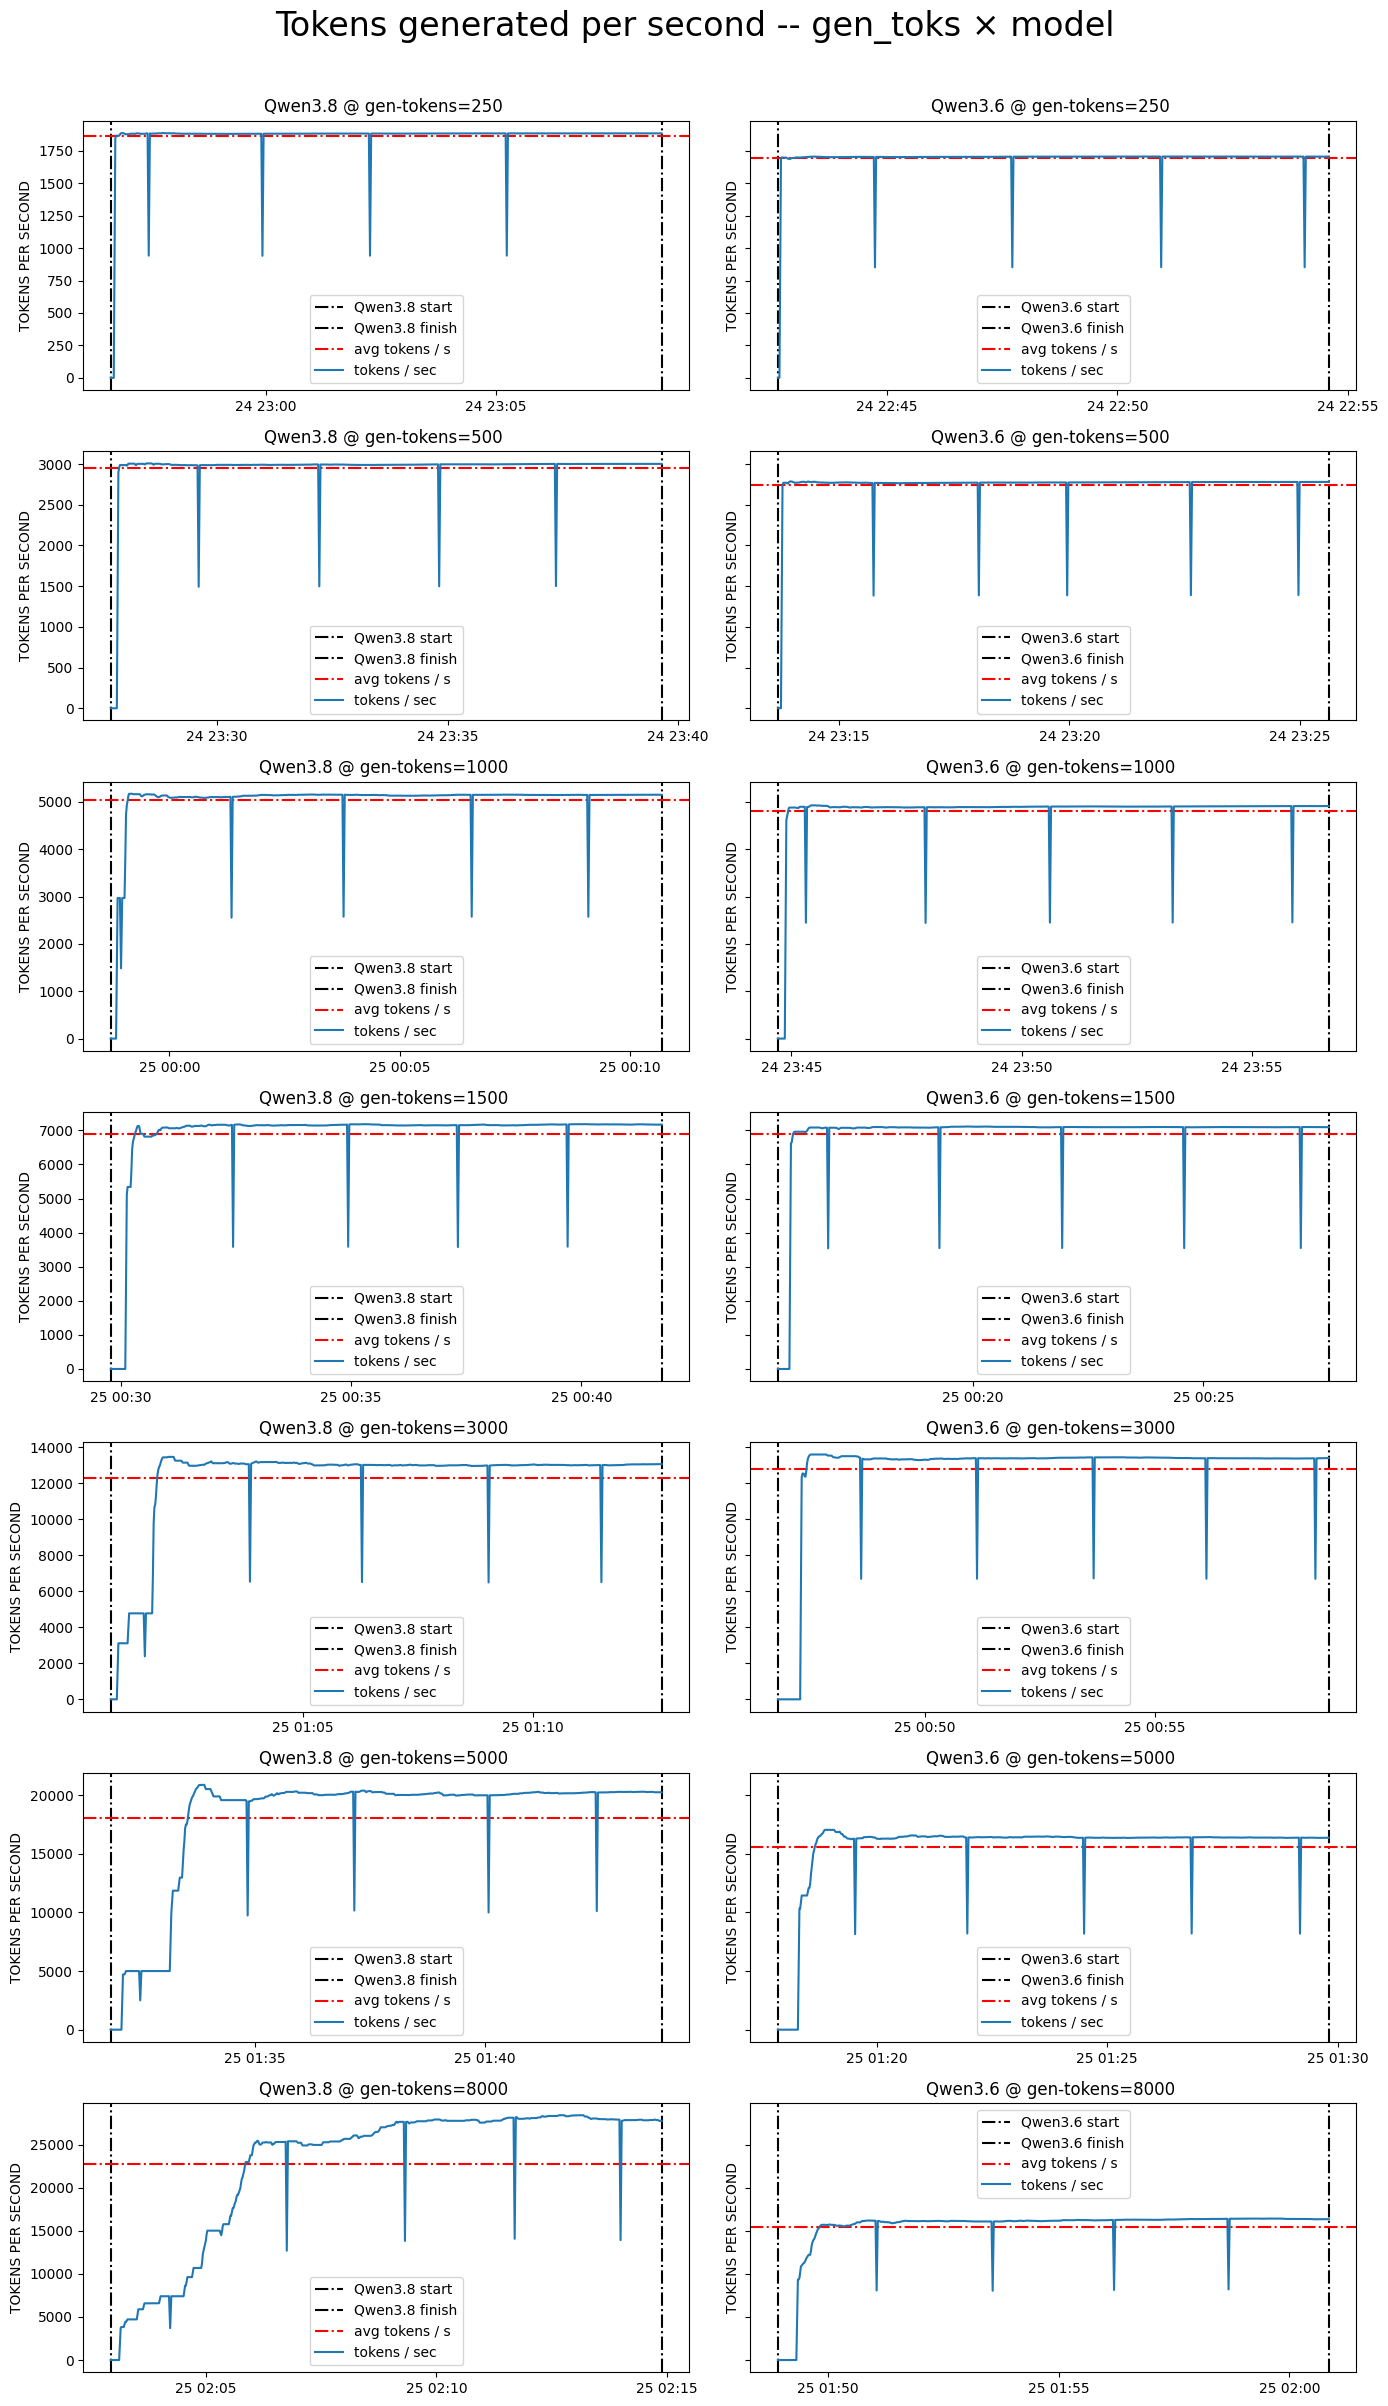

In [6]:
# --- setup grid ---
toks_list = sorted([int(x) for x in LCST[MODELS[0]].keys()])          # chiavi gen_toks (stesse per tutti)
toks_list = [str(x) for x in toks_list]
n_rows, n_cols = len(toks_list), len(MODELS)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(14, 3.5 * n_rows),
                         sharex=False,
                         sharey="row"
                        )

# flatten axes se n_rows == 1 (altrimenti 2D array)
if n_rows == 1:
    axes = [axes]

for r, toks in enumerate(toks_list):
    for c, m in enumerate(MODELS):
        ax = axes[r][c] if n_rows > 1 else axes[c]
        
        df = LCST[m][toks]
        dts = df["Timestamp"][1:] - df["Timestamp"][:-1]
        tokens_per_sec = 0.5 * (df["Total Average Content Size"][1:] + df["Total Average Content Size"][:-1]) / dts
        centers = 0.5 * (df["Timestamp"][1:] + df["Timestamp"][:-1]) 
        centers = df.select(pl.from_epoch(centers, time_unit="s"))
        start, finish = centers[0], centers[-1]

        # Calculate on the whole process, TODO: maybe it's more relevant to skip the "activation-transient" ??
        avg_toks_s = tokens_per_sec.mean()
        RESULTS[m][toks]["avg_toks_s"] = avg_toks_s 
        
        ax.axvline(start, label=f"{m} start", color='black', ls="-.")
        ax.axvline(finish, label=f"{m} finish", color='black', ls="-.")
        ax.axhline(avg_toks_s, color="r", ls="-.", label="avg tokens / s")
        ax.plot(centers, tokens_per_sec, label="tokens / sec")
        ax.set_ylabel("TOKENS PER SECOND")
        ax.set_title(f"{m} @ gen-tokens={toks} ")
        ax.legend()
plt.suptitle("Tokens generated per second -- gen_toks × model", fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Active Gpu usage        [[ nvidia_smi.utilization_gpu ]]

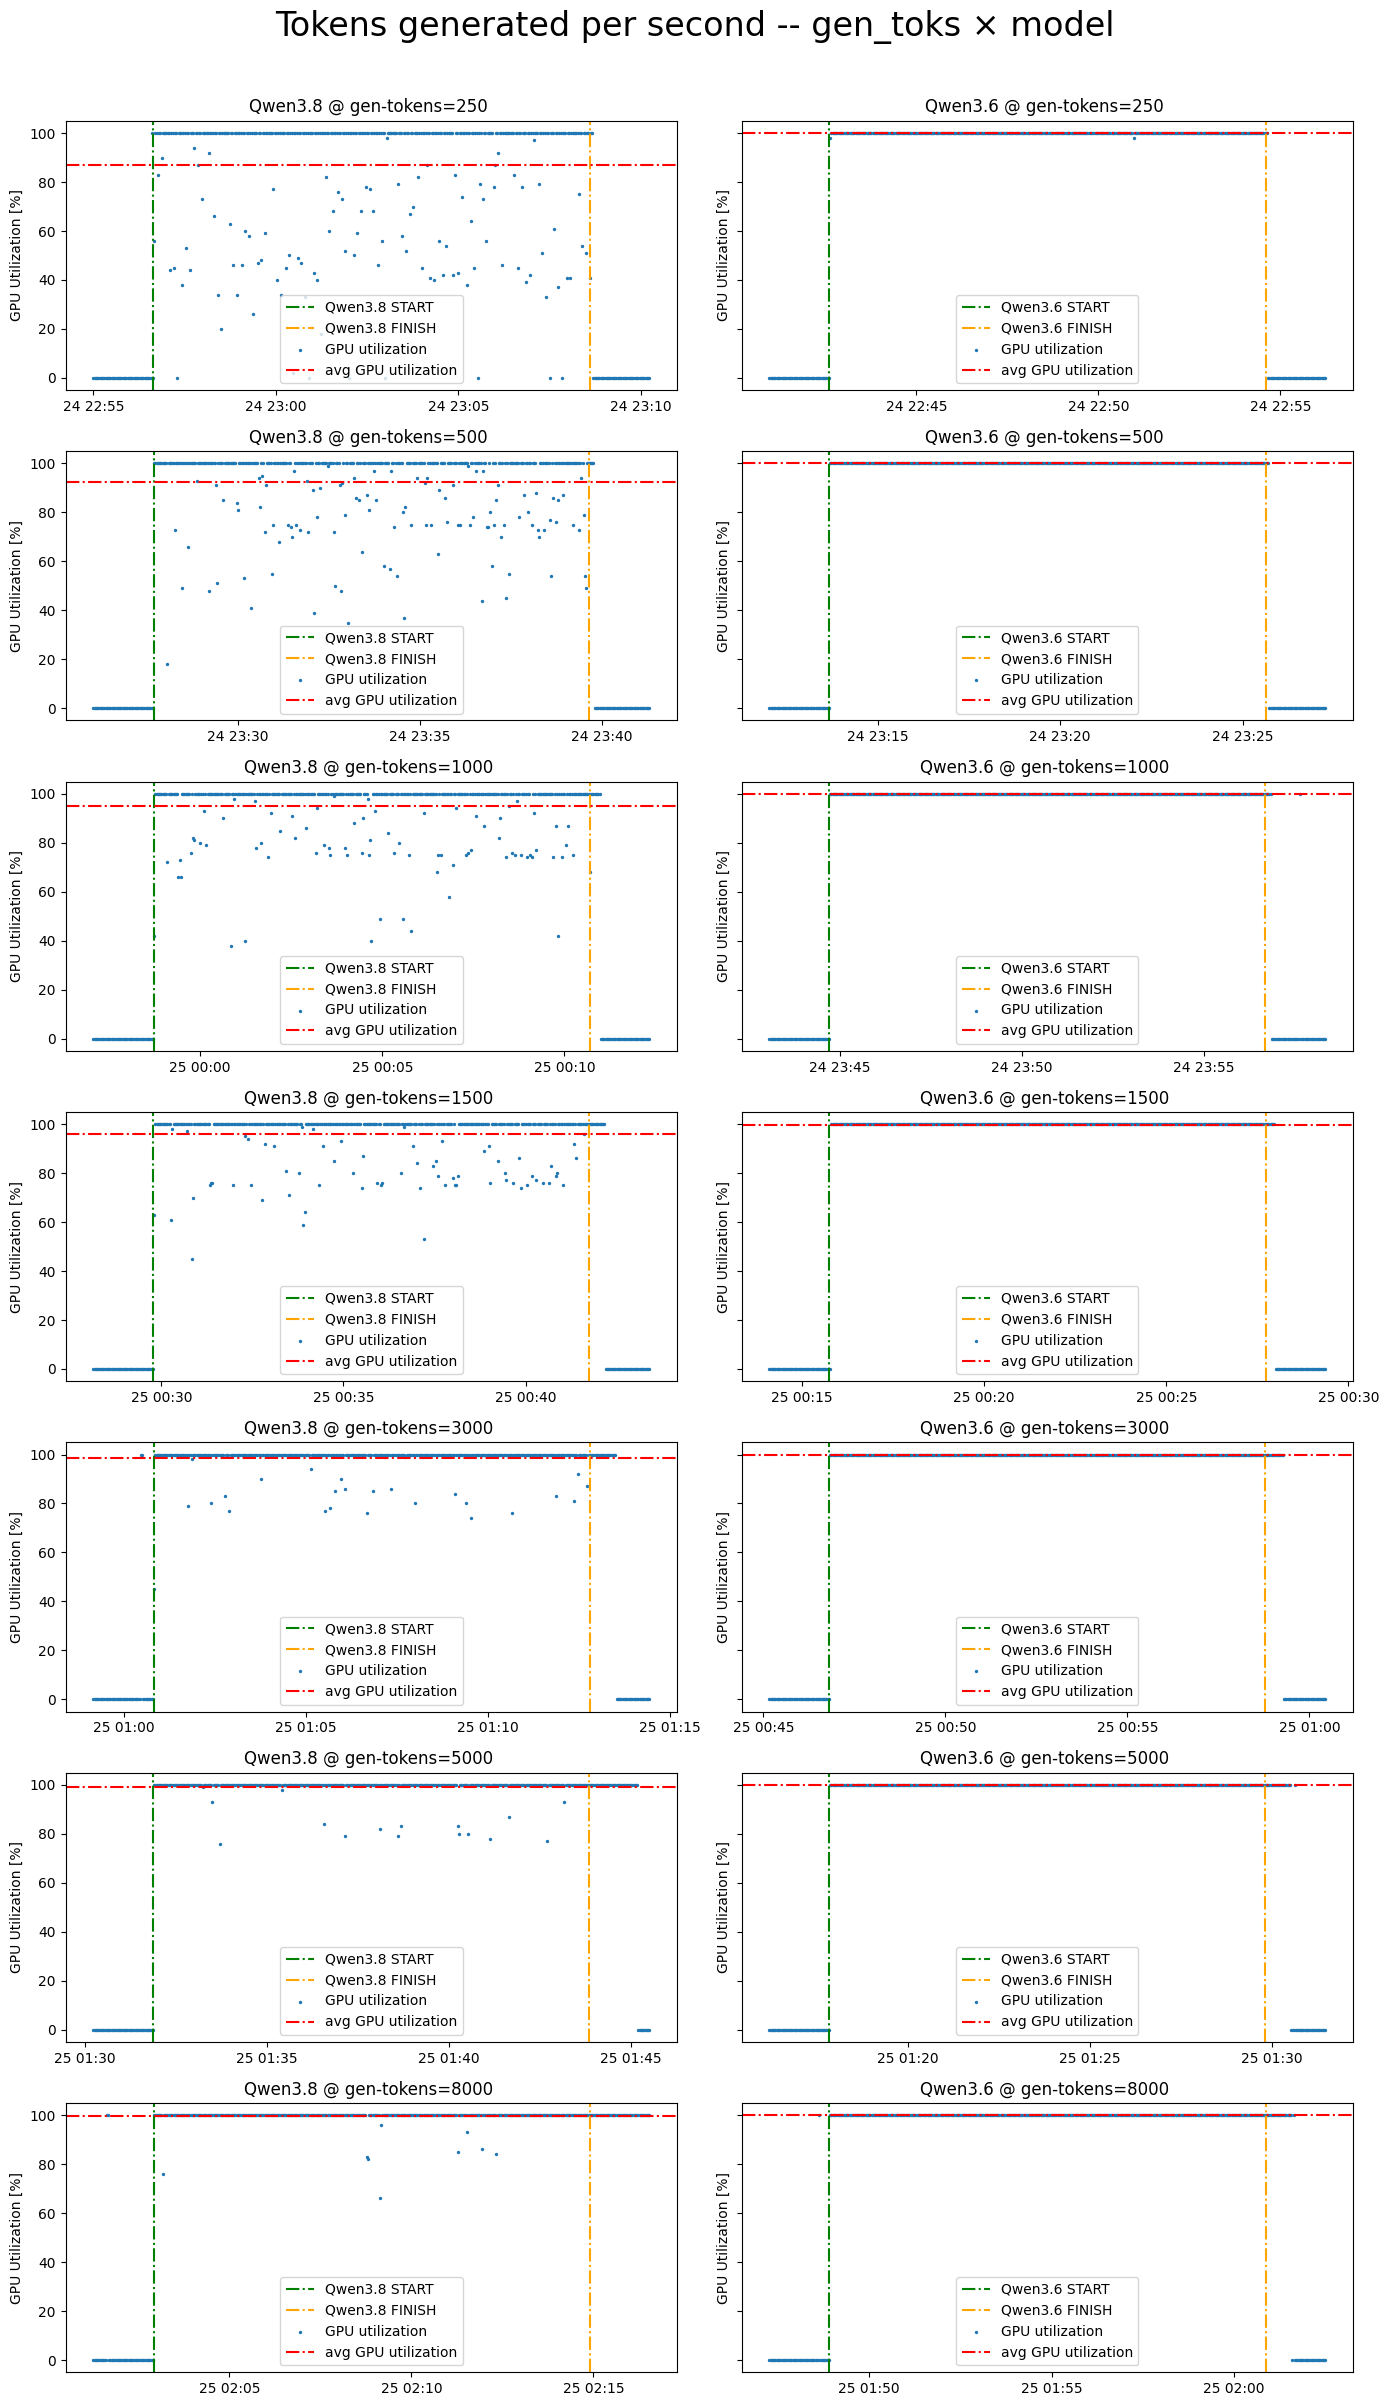

In [7]:
# --- setup grid ---
toks_list = sorted([int(x) for x in LCST[MODELS[0]].keys()])          # chiavi gen_toks (stesse per tutti)
toks_list = [str(x) for x in toks_list]
n_rows, n_cols = len(toks_list), len(MODELS)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(14, 3.5 * n_rows),
                         sharex=False,
                         sharey="row"
                        )

# flatten axes se n_rows == 1 (altrimenti 2D array)
if n_rows == 1:
    axes = [axes]

for r, toks in enumerate(toks_list):
    for c, m in enumerate(MODELS):
        ax = axes[r][c] if n_rows > 1 else axes[c]
        
        gpu_index = RESULTS[m][toks]["index_GPU"]
        proc = LCST[m][toks]
        df = DB["nvidia_smi"]
        start, finish = min(proc["Timestamp"]), max(proc["Timestamp"])
        delta = 100 # Adding some pre and post process power usage data
        df = df.filter(pl.col("index") == gpu_index)
        df = df.filter(pl.col("Timestamp").is_between(start - delta, finish + delta, closed="none"))

        start_dt = datetime.fromtimestamp(start, timezone.utc)
        finish_dt = datetime.fromtimestamp(finish, timezone.utc)
        ax.axvline(start_dt, label=f"{m} START", color='green', ls="-.")
        ax.axvline(finish_dt, label=f"{m} FINISH", color='orange', ls="-.")
        ax.scatter(df["Datetime"], df["utilization_gpu"], s=2.0, label="GPU utilization")

        df = df.filter(pl.col("Timestamp").is_between(start, finish, closed="none"))
        avg_gpu_utilization = df["utilization_gpu"].mean()
        RESULTS[m][toks]["avg_gpu_utilization"] = avg_gpu_utilization

        ax.axhline(avg_gpu_utilization, color="r", ls="-.",lw=1.5, label=f"avg GPU utilization")
        ax.set_ylabel("GPU Utilization [%]")
        ax.set_title(f"{m} @ gen-tokens={toks} ")
        ax.legend()

plt.suptitle("Tokens generated per second -- gen_toks × model", fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Active GPU energy per 1000 tokens
### -> Calculated as (Total_energy_at_GPU) / (Total_tokens)

In [8]:
# Calculate total energy at GPU

for toks in GEN_TOKENS:
    for m in MODELS:
        proc = LCST[m][toks]
        start, finish = min(proc["Timestamp"]), max(proc["Timestamp"])
        gpu_idx = RESULTS[m][toks]["index_GPU"]
        df = (DB["nvidia_smi"]
                .filter((pl.col("index") == gpu_idx) &
                        pl.col("Timestamp").is_between(start, finish, closed="none"))
                .sort("Timestamp"))

        ts = df["Timestamp"].to_numpy()                    # secondi
        p  = df["power_draw"].to_numpy()                   # Watt
        energy_J = float(np.trapezoid(p, x=ts))    # Joule
        energy_Wh = energy_J / 3600

        # Calculate tokens generated from start to finish 
        toks_total = proc["Total Average Content Size"][-1] * proc["Total Request Count"][-1]
        print(f"energy [Wh] / k toks_total = {(1000 * energy_Wh / toks_total):.5f}")

        print(f"energy used by {m} @ {toks} = {energy_Wh} Wh")

#TODO------------------------------------

'''
# --- setup grid ---
toks_list = sorted([int(x) for x in LCST[MODELS[0]].keys()])          # chiavi gen_toks (stesse per tutti)
toks_list = [str(x) for x in toks_list]
n_rows, n_cols = len(toks_list), len(MODELS)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(14, 3.5 * n_rows),
                         sharex=False,
                         sharey="row"
                        )

# flatten axes se n_rows == 1 (altrimenti 2D array)
if n_rows == 1:
    axes = [axes]
#TODO-------------------------------------
#'''

energy [Wh] / k toks_total = 0.01186
energy used by Qwen3.8 @ 250 = 97.4040472222222 Wh
energy [Wh] / k toks_total = 0.00805
energy used by Qwen3.6 @ 250 = 87.76282499999999 Wh
energy [Wh] / k toks_total = 0.01376
energy used by Qwen3.8 @ 500 = 101.70121666666667 Wh
energy [Wh] / k toks_total = 0.00861
energy used by Qwen3.6 @ 500 = 90.1338888888889 Wh
energy [Wh] / k toks_total = 0.01513
energy used by Qwen3.8 @ 1000 = 105.05253333333333 Wh
energy [Wh] / k toks_total = 0.00904
energy used by Qwen3.6 @ 1000 = 91.14617500000001 Wh
energy [Wh] / k toks_total = 0.01595
energy used by Qwen3.8 @ 1500 = 106.72843333333333 Wh
energy [Wh] / k toks_total = 0.00933
energy used by Qwen3.6 @ 1500 = 92.32411944444443 Wh
energy [Wh] / k toks_total = 0.01800
energy used by Qwen3.8 @ 3000 = 110.08708611111112 Wh
energy [Wh] / k toks_total = 0.01009
energy used by Qwen3.6 @ 3000 = 93.82373333333334 Wh
energy [Wh] / k toks_total = 0.02013
energy used by Qwen3.8 @ 5000 = 112.66 Wh
energy [Wh] / k toks_to

'\n# --- setup grid ---\ntoks_list = sorted([int(x) for x in LCST[MODELS[0]].keys()])          # chiavi gen_toks (stesse per tutti)\ntoks_list = [str(x) for x in toks_list]\nn_rows, n_cols = len(toks_list), len(MODELS)\n\nfig, axes = plt.subplots(n_rows, n_cols,\n                         figsize=(14, 3.5 * n_rows),\n                         sharex=False,\n                         sharey="row"\n                        )\n\n# flatten axes se n_rows == 1 (altrimenti 2D array)\nif n_rows == 1:\n    axes = [axes]\n#TODO-------------------------------------\n#'

# COMMENTS on RESULTS <br>
    avg_power_at_GPU :    meglio isolare la stima dopo il transiente iniziale <br>
    avg_toks_s :    meglio isolare la stima dopo il transiente ? <br>
    avg_gpu_usage :    è fisso a 100% meno alcune misure a spot, realmente interessante? o più un check ? <br>


# VA RISOLTO CHE FERMO L'OSSERVAZIONE AL MOMENTO IN CUI PARTONO LE ULTIME CHIAMATE
# MAGARI LA COSA MIGLIORE è PRENDERE IL TEMPO MASSIMO E USARE QUELLO.
# NON FARLO SIGNIFICA IGNORARE L'ENERGIA UTILIZZATA ALLA FINE
# QUESTA CORREZIONE FA SI CHE I "TRANSIENTI" FINALI SIANO CONSIDERATI
# PERò FARLO SIGNIFICA INCLUDERE DATI NON A PIENO CARICO
# QUINDI VA SCELTO COSA FARE, SECONDO ME RESTA MEGLIO GUARDARE SOLO I DATI A PIENO CARICO...

In [9]:
# Un check veloce

df = pl.read_csv("./logs/stats_Qwen3.8_t5000__stats.csv")
print(df["Name", "Average Content Size", "Request Count"])
print(f"tokens_total = {tokens_total_cross_verify}")
proc["Average Content Size"]

shape: (2, 3)
┌─────────────────┬──────────────────────┬───────────────┐
│ Name            ┆ Average Content Size ┆ Request Count │
│ ---             ┆ ---                  ┆ ---           │
│ str             ┆ f64                  ┆ i64           │
╞═════════════════╪══════════════════════╪═══════════════╡
│ Qwen3.8 Request ┆ 20207.472924         ┆ 277           │
│ Aggregated      ┆ 20207.472924         ┆ 277           │
└─────────────────┴──────────────────────┴───────────────┘


NameError: name 'tokens_total_cross_verify' is not defined

In [ ]:
LCST["Qwen3.8"]["5000"]["Timestamp", "Total Average Content Size", "Requests/s","Total Request Count"][-300:]


Timestamp,Total Average Content Size,Requests/s,Total Request Count
i64,f64,f64,i64
1790300330,20150.366013,0.7,153
1790300331,20099.748387,0.6,155
1790300332,20140.280255,0.8,157
1790300333,20140.280255,0.8,157
1790300334,20166.601266,1.0,158
…,…,…,…
1790300627,20238.872263,0.4,274
1790300628,20238.872263,0.4,274
1790300629,20240.069091,0.4,275


In [ ]:
LCST["Qwen3.8"]["5000"].columns

['Timestamp',
 'User Count',
 'Type',
 'Name',
 'Requests/s',
 'Failures/s',
 '50%',
 '66%',
 '75%',
 '80%',
 '90%',
 '95%',
 '98%',
 '99%',
 '99.9%',
 '99.99%',
 '100%',
 'Total Request Count',
 'Total Failure Count',
 'Total Median Response Time',
 'Total Average Response Time',
 'Total Min Response Time',
 'Total Max Response Time',
 'Total Average Content Size',
 'Datetime']

[datetime.datetime(2026, 9, 24, 22, 57, 8, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 9, 24, 22, 58, 8, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 9, 24, 22, 59, 8, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 9, 24, 23, 0, 8, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 9, 24, 23, 1, 8, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 9, 24, 23, 2, 8, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 9, 24, 23, 3, 8, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 9, 24, 23, 4, 8, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 9, 24, 23, 5, 8, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 9, 24, 23, 6, 8, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 9, 24, 23, 7, 8, tzinfo=datetime.timezone.utc)] [11270.7, 11299.266666666666, 11269.9, 11304.0, 11320.466666666667, 11296.616666666667, 11332.633333333333, 11610.233333333334, 11341.416666666666, 12279.216666666667, 11295.45]
[datetime.datetime(2026, 9

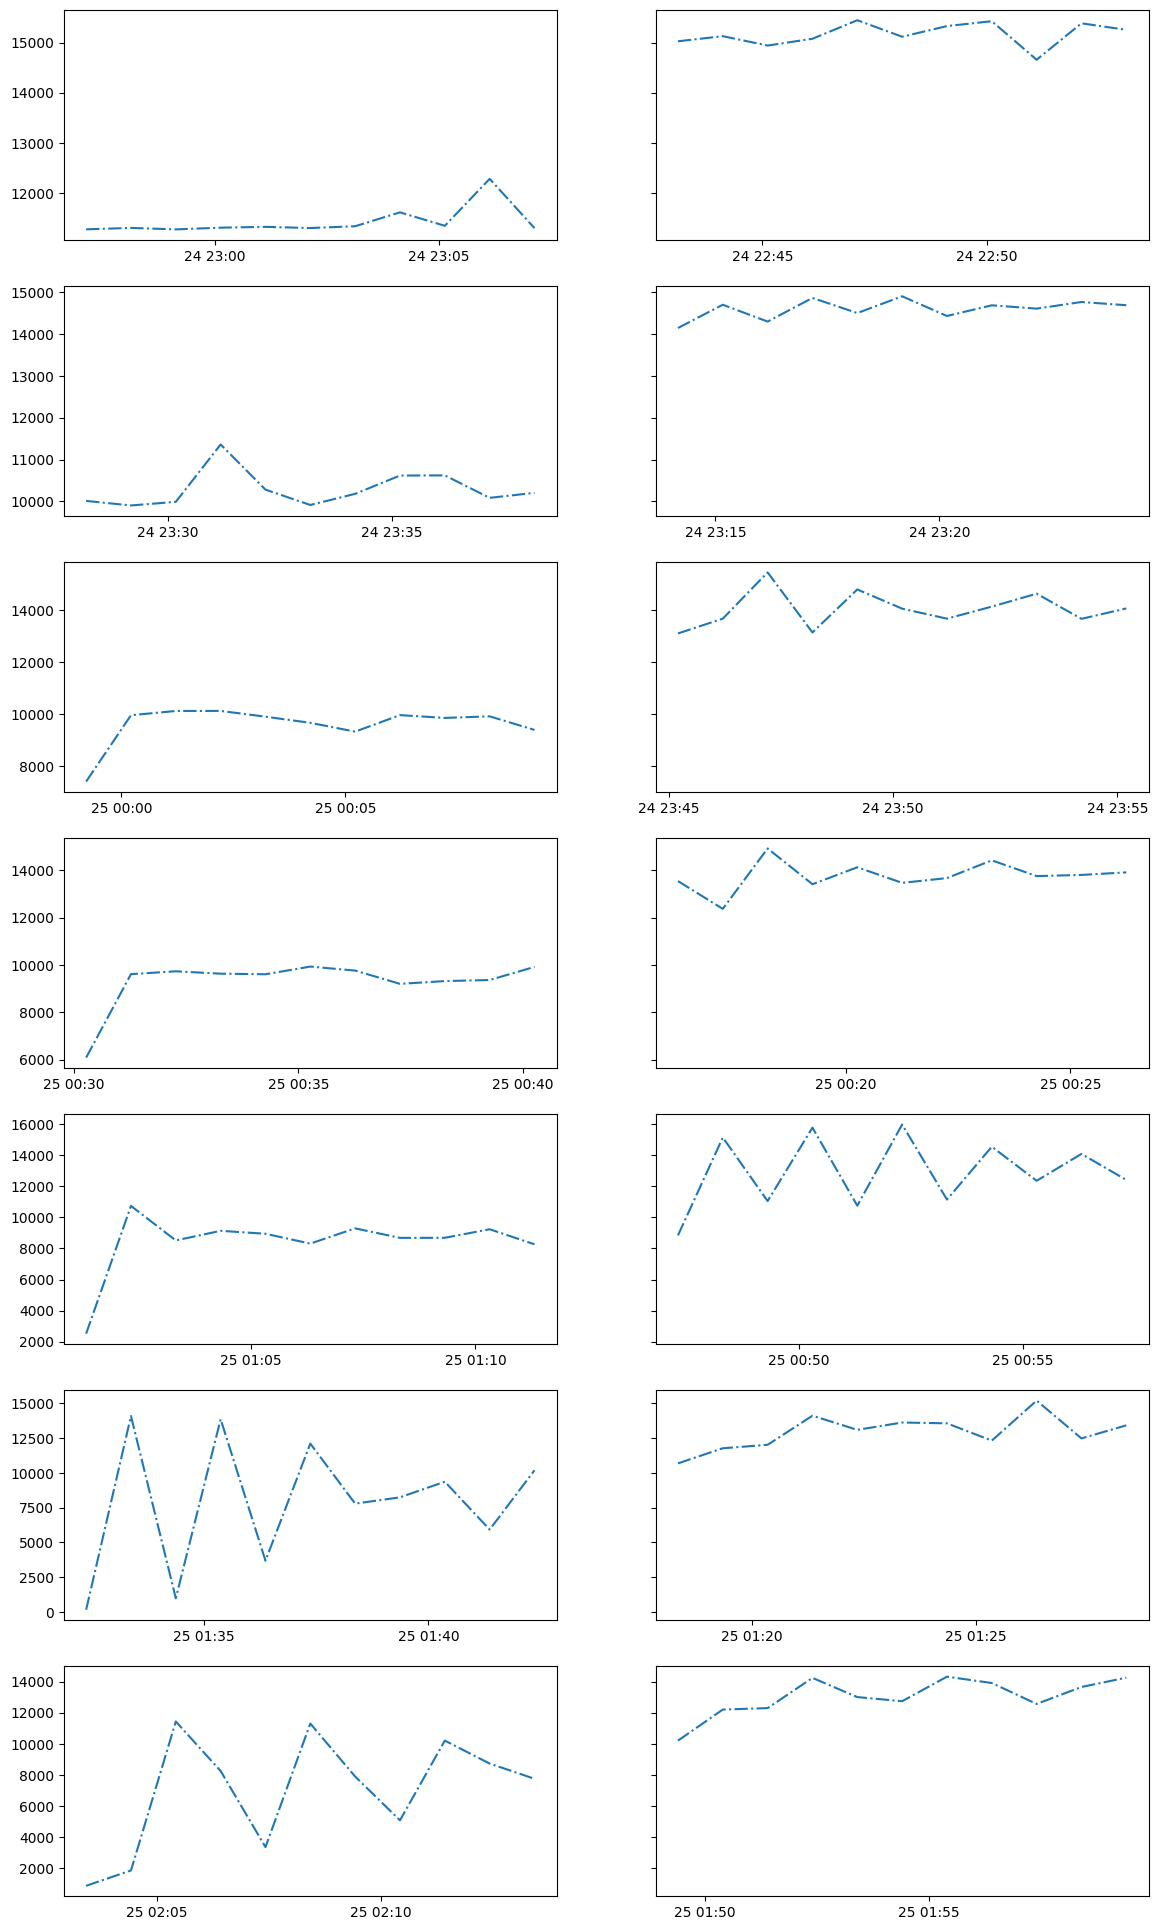

In [49]:
# --- setup grid ---
toks_list = sorted([int(x) for x in LCST[MODELS[0]].keys()])          # chiavi gen_toks (stesse per tutti)
toks_list = [str(x) for x in toks_list]
n_rows, n_cols = len(toks_list), len(MODELS)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(14, 3.5 * n_rows),
                         sharex=False,
                         sharey="row"
                        )

# flatten axes se n_rows == 1 (altrimenti 2D array)
if n_rows == 1:
    axes = [axes]

for r, toks in enumerate(toks_list):
    for c, m in enumerate(MODELS):
        ax = axes[r][c] if n_rows > 1 else axes[c]
        
        df = LCST[m][toks]
        #dts = df["Timestamp"][1:] - df["Timestamp"][:-1]
        #tokens_per_sec = 0.5 * (df["Total Average Content Size"][1:] + df["Total Average Content Size"][:-1]) / dts
        #centers = 0.5 * (df["Timestamp"][1:] + df["Timestamp"][:-1]) 
        #centers = df.select(pl.from_epoch(centers, time_unit="s"))
        #start, finish = centers[0], centers[-1]
        start, finish = min(df["Timestamp"]), max(df["Timestamp"])
        # Calculate the content in generated during timewindows of width dt
        dt = 60     # seconds
        time_total = finish - start
        n_winds = int(time_total // dt)      # i want integers, this corrupts eventually the last seconds of the experiment
        centers = []
        tokens = []
        for b in range(n_winds):
            left = start + b * dt
            right = left + dt
            df_l = df.filter(df["Timestamp"] == left)
            df_r = df.filter(df["Timestamp"] == right)
            if len(df_l) != 1 or len(df_r) != 1:
                print(f"Some inconsistency at: Timestamp: {left}  OR  {right}\nFor model {m} @ {toks}")
                continue

            req_l = df_l["Total Request Count"][0]
            req_r = df_r["Total Request Count"][0]
            tokens_in_bin = (1 / dt) * (req_r * df_r["Total Average Content Size"][0] - req_l * df_l["Total Average Content Size"][0])
            tokens.append(tokens_in_bin)
            center_timestamp = left + dt / 2
            centers.append(datetime.fromtimestamp(center_timestamp, tz=timezone.utc))
        print(centers, tokens)
        ax.plot(centers, tokens,ls="-.")


#--------------------------------
'''        # Calculate on the whole process, TODO: maybe it's more relevant to skip the "activation-transient" ??
        avg_toks_s = tokens_per_sec.mean()
        RESULTS[m][toks]["avg_toks_s"] = avg_toks_s 
        
        ax.axvline(start, label=f"{m} start", color='black', ls="-.")
        ax.axvline(finish, label=f"{m} finish", color='black', ls="-.")
        ax.axhline(avg_toks_s, color="r", ls="-.", label="avg tokens / s")
        ax.plot(centers, tokens_per_sec, label="tokens / sec")
        ax.set_ylabel("TOKENS PER SECOND")
        ax.set_title(f"{m} @ gen-tokens={toks} ")
        ax.legend()
plt.suptitle("Tokens generated per second -- gen_toks × model", fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.97])
'''
plt.show()

In [29]:
df_l["Total Average Content Size"][0]

16370.288848263253